#Study of S&P 500 Index

**Problem Statement:** We investigate the effects of the coronavirus disease 2019 (COVID-19) cases
in the U.S. on the S&P 500 Index using daily data covering the period between March 1st, 2020 and April 29th, 2022. And then try to predict some closing values using historical data.

Historical decomposition of the S&P 500 Index suggests that the negative effects of
COVID-19 cases on the S&P 500 Index have been mostly observed during
March 2020.

**Stationarity:** Time series data that is used for statistical analysis is stationary in order to perform statistical modeling correctly, as such usages may be for prediction and forecasting. Otherwise, modeling from non-stationary data may produce unpredictable results. A stationary time series is one whose statistical properties, such as mean, variance, and autocorrelation, are constant over time.

**Checking for stationarity:** We used `Augmented Dickey-Fuller Test` to check if stationarity expectations have been met or violated.

**Forecasting and predicting a time series** We identified non-stationarity in time series data and made the data stationary. With stationary data, we can proceed to perform statistical modeling such as prediction and forecasting. Prediction involves generating best estimates of in-sample data. Forecasting involves generating best estimates of out-of-sample data. Predicting future values is based on previously observed values. One such commonly used method is the Autoregressive Integrated Moving Average(ARIMA). We then plot the predicted and forecasted prices against our original dataset, from 2020 onwards.


**Dataset:** We have used `yfinance` package to import our `S&P` data.

In [113]:
!pip install yfinance
!pip install pandas==1.1.3

  Using cached pandas-1.1.3.tar.gz (5.2 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [114]:
!pip install statsmodels==0.11.0

  Using cached statsmodels-0.11.0.tar.gz (15.4 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Dataset:** We have used `yfinance` package to import our s&p data.

In [115]:
import pandas as pd
import numpy as np
import yfinance as yahooFinance

import matplotlib.pyplot as plt

import datetime

# startDate , as per our convenience we can modify
startDate = datetime.datetime(2020, 3, 1)
endDate = datetime.datetime(2023, 3, 28)

GetsnpInformation = yahooFinance.Ticker("QQQ")

# pass the parameters as the taken dates for start and end
df = GetsnpInformation.history(start=startDate, end= endDate)

In [116]:
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2023-03-21 00:00:00-04:00,304.037586,306.861328,302.517093,306.407166,49757000,0.0,0.0,0.0
2023-03-22 00:00:00-04:00,306.337972,311.254871,302.072741,302.240570,75791900,0.0,0.0,0.0
2023-03-23 00:00:00-04:00,305.992474,310.168849,303.119348,305.824615,74576000,0.0,0.0,0.0
2023-03-24 00:00:00-04:00,305.400084,307.048904,303.060123,306.950195,57195200,0.0,0.0,0.0
2023-03-27 00:00:00-04:00,307.651174,308.737240,303.988198,304.847168,50287400,0.0,0.0,0.0


In [117]:
dfnew = df.drop(columns = ['Dividends', 'Stock Splits'])
dfnew.head()

,Open,High,Low,Close,Volume,Capital Gains
Date,,,,,,
2020-03-02 00:00:00-05:00,202.276044,209.722918,199.428992,209.577652,112933900,0.0
2020-03-03 00:00:00-05:00,210.245877,212.666837,201.055906,202.857101,131953500,0.0
2020-03-04 00:00:00-05:00,206.575694,211.427293,204.687334,211.320770,73086200,0.0
2020-03-05 00:00:00-05:00,205.965619,209.519587,203.457508,204.900391,78705500,0.0
2020-03-06 00:00:00-05:00,198.199145,202.537501,196.494795,201.443237,89828400,0.0


Plotting the data

<Axes: xlabel='Date'>

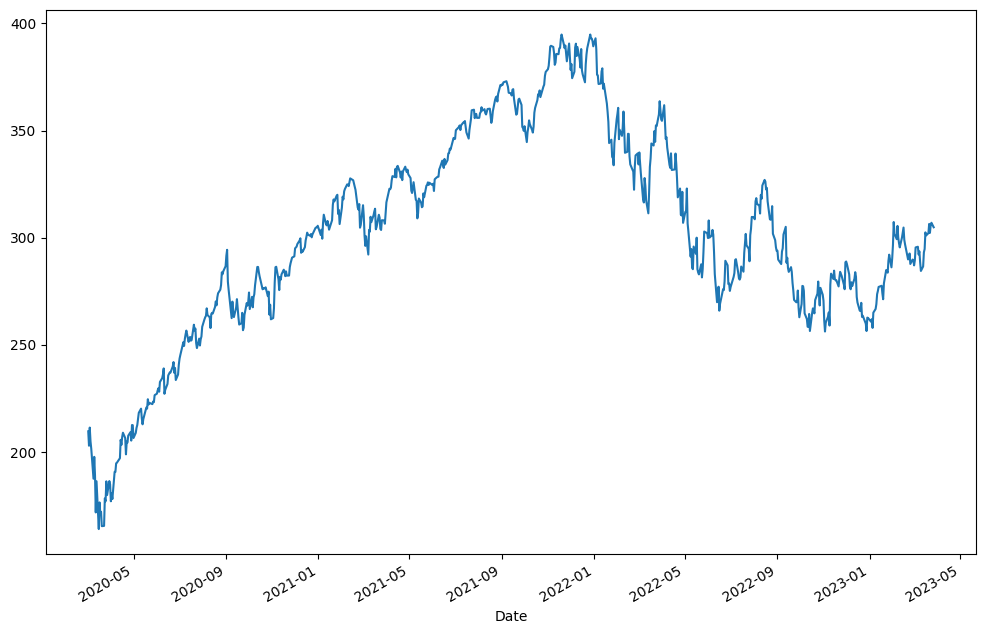

In [118]:
dfnew['Close'].plot(figsize=(12, 8))
# xcoords = ['2020-04-01', '2020-07-01','2020-10-01', '2021-01-01', '2021-04-01', '2021-07-01',
#           '2021-10-01','2022-01-01','2022-04-01']
# for xc in xcoords:
#     plt.axvline(x=xc, color='black', linestyle='--')

Trend and Seasonality check


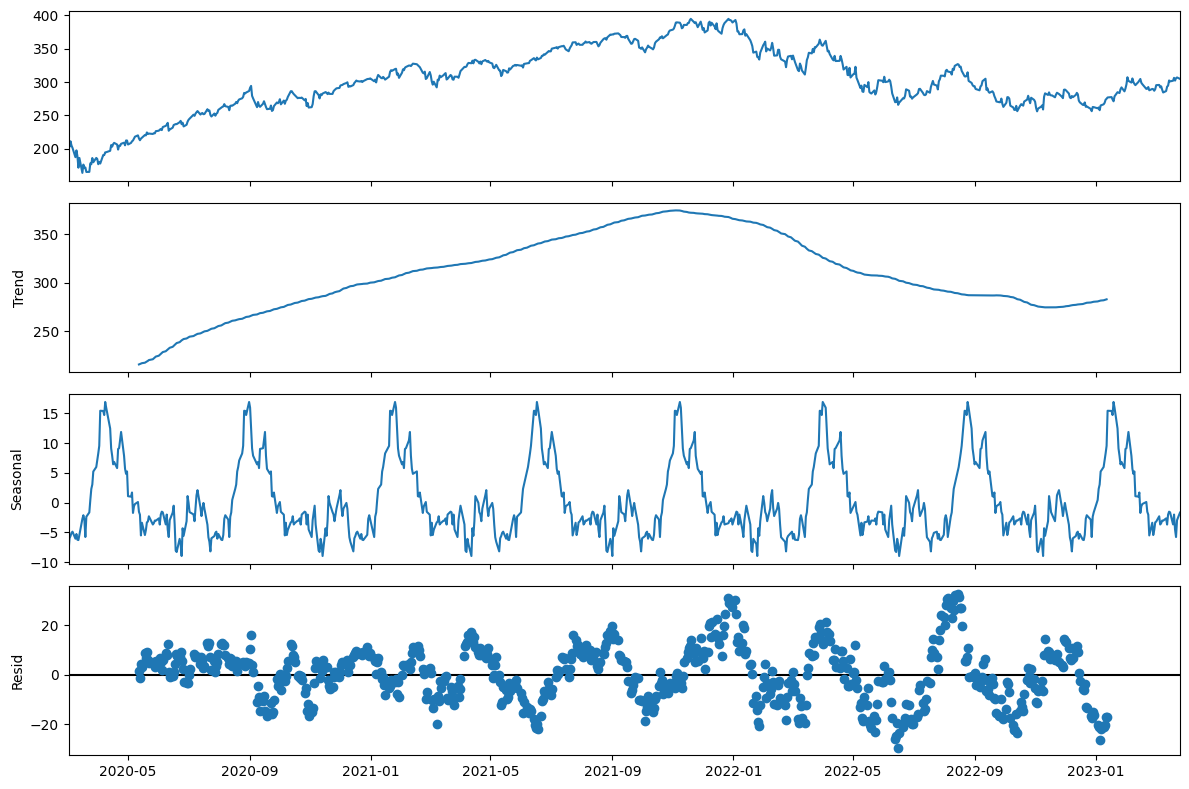

In [119]:
from statsmodels.tsa.seasonal import seasonal_decompose

analysis = dfnew[['Close']].copy()
#analysis = dfnew['Close'].resample('MS').

analysis.index = pd.to_datetime(dfnew.index)

decompose_result_mult = seasonal_decompose(analysis, model="additive", period =100)

trend = decompose_result_mult.trend
seasonal = decompose_result_mult.seasonal
residual = decompose_result_mult.resid

plt.rcParams["figure.figsize"] = (12, 8)
fig = decompose_result_mult.plot()

Confirming the Seasonality with Periodogram

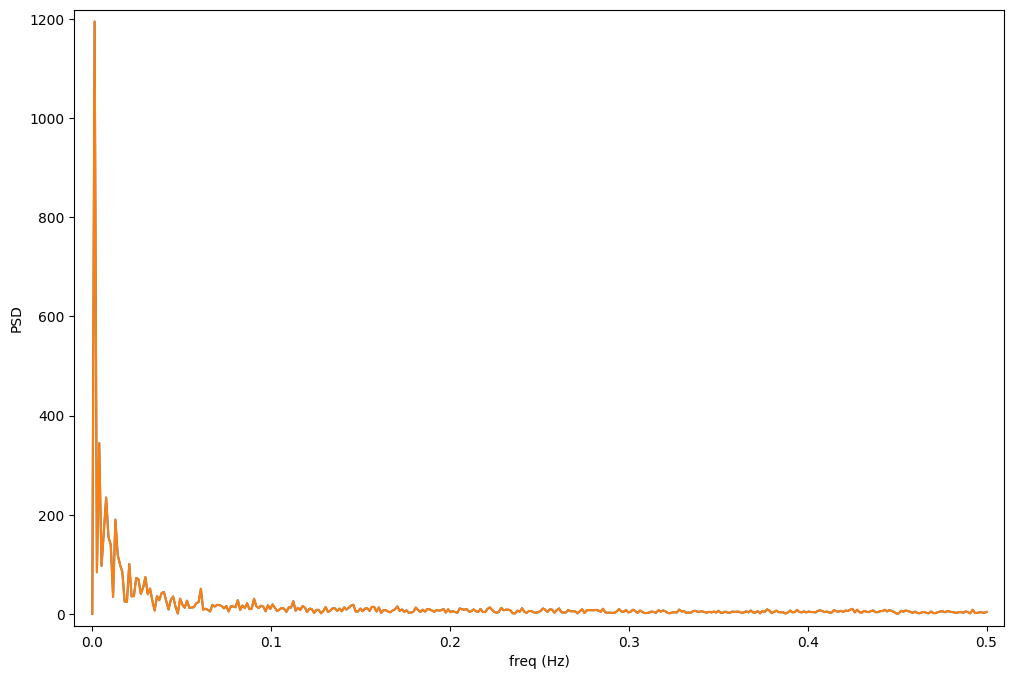

In [120]:
import scipy
# Determine frequencies
# f = np.fft.fftfreq(len(dfnew)) * sampling_freq

# # Compute power spectral density
# psd = np.abs(np.fft.fft(dfnew.values))**2 / len(dfnew)

f, psd = scipy.signal.periodogram(analysis['Close'])
# Make plot
plt.plot(f, np.sqrt(psd))
plt.xlabel('freq (Hz)')
plt.ylabel('PSD')
plt.margins(0.02)
plt.rcParams["figure.figsize"] = (25, 8)
fig = plt.plot(f, np.sqrt(psd))

Stationarity Cheack on raw data

In [121]:
from statsmodels.tsa.stattools import adfuller

x = analysis.dropna()
dftest = adfuller(x)

print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -2.0565251227953776
2. P-Value :  0.2623513556822151
3. Num Of Lags :  0
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 773
5. Critical Values :
	 1% :  -3.438837902109151
	 5% :  -2.8652862410999114
	 10% :  -2.568764869203001


Log Transformation: We perform detrending on the same dataset with logarithmic transformation and subtracting from the moving average of two periods, as given

<Axes: title={'center': 'Original Values'}, xlabel='Date'>

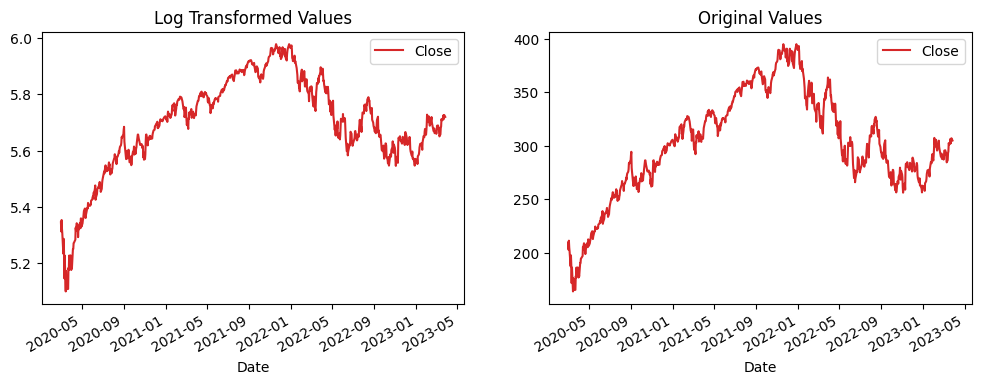

In [122]:
logged_closevalues = analysis.apply(lambda x : np.log(x))
ax1 = plt.subplot(121)
logged_closevalues.plot(figsize=(12,4) ,color="tab:red", title="Log Transformed Values", ax=ax1)
ax2 = plt.subplot(122)
analysis.plot(color="tab:red", title="Original Values", ax=ax2)

Dicky fuller test after log transformation. The p-value for this detrended data is less than 0.05. Our ADF test statistic is lower than all the critical values. We can reject the null hypothesis and say that this data is stationary.

In [123]:
from statsmodels.tsa.stattools import adfuller

x = logged_closevalues.dropna()
dftest = adfuller(x)

print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -3.7306468882054236
2. P-Value :  0.0037021568080572685
3. Num Of Lags :  10
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 763
5. Critical Values :
	 1% :  -3.4389495235166416
	 5% :  -2.8653354363373253
	 10% :  -2.56879107669766


Removing the trend using Moving Window Function on Log Transformed Time-Series

We Compute the rolling mean and standard deviation into the df_mean and df_std variables, respectively, with a window period of one year.

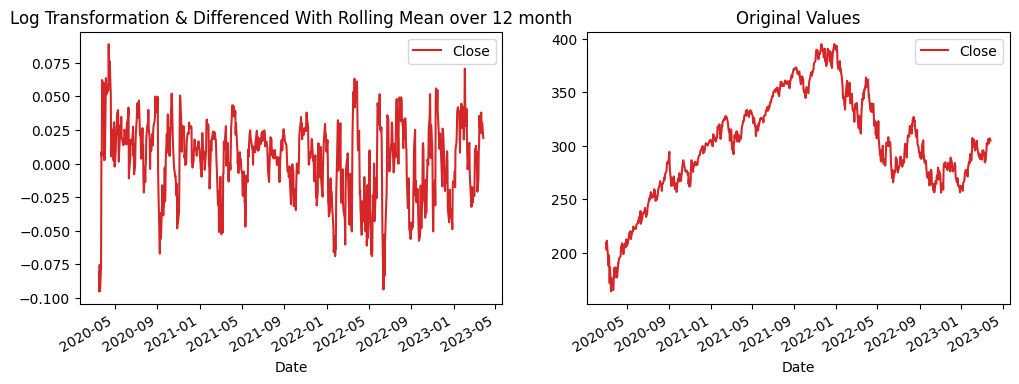

In [124]:
rolling_mean = logged_closevalues.rolling(window = 12).mean()
price_log_rolled_detrended = logged_closevalues - rolling_mean

ax1 = plt.subplot(121)
price_log_rolled_detrended.plot(figsize=(12,4),color="tab:red", title="Log Transformation & Differenced With Rolling Mean over 12 month", ax=ax1);
ax2 = plt.subplot(122)
analysis.plot(figsize=(12,4), color="tab:red", title="Original Values", ax=ax2);

Seasonal decomposing: Decomposing involves modeling both the trend and seasonality, and then removing them. We can use the statsmodel.tsa.seasonal module to model a non-stationary time series dataset using moving averages and remove its trend and seasonal components.

The individual trend and seasonality components being removed from the dataset and plotted, and the residuals plotted at the bottom.

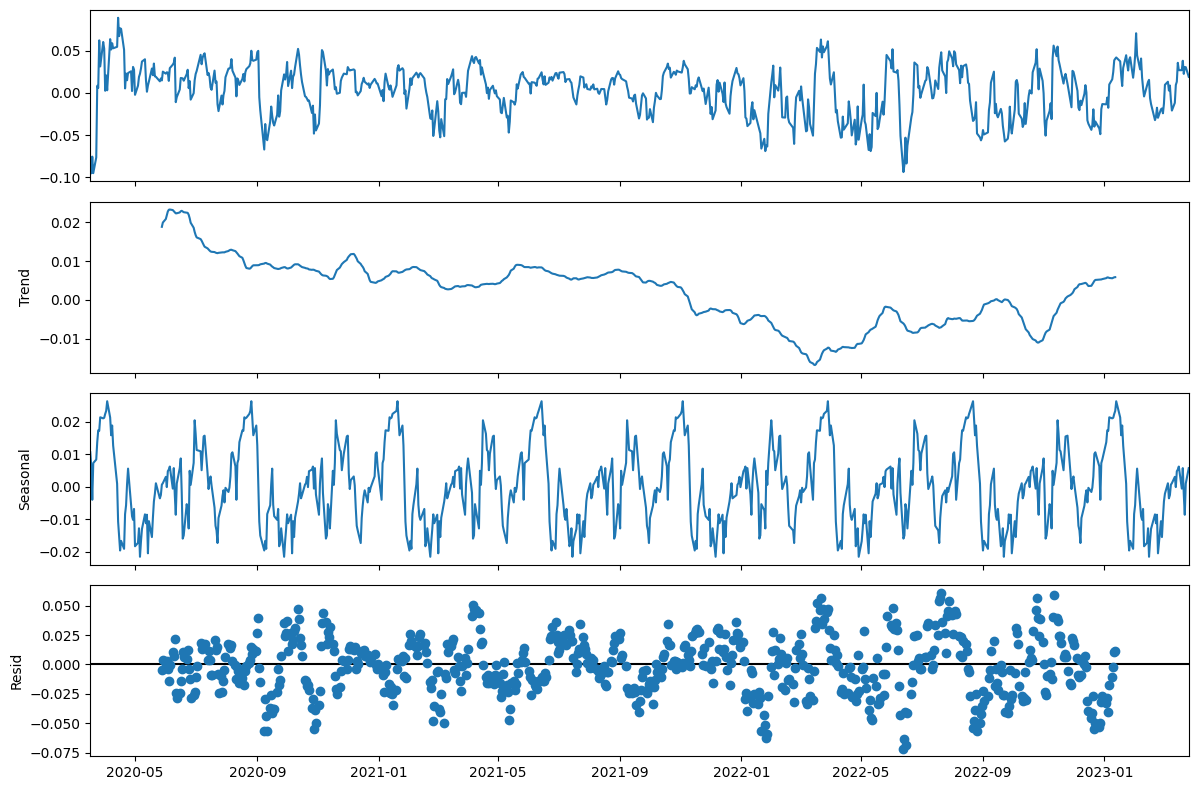

In [125]:
decompose_result = seasonal_decompose(price_log_rolled_detrended.dropna(), model="additive", period=100)

trend = decompose_result.trend
seasonal = decompose_result.seasonal
residual = decompose_result.resid

plt.rcParams["figure.figsize"] = (12, 8)
fig = decompose_result.plot()

In [126]:
price_log_rolled_detrended = price_log_rolled_detrended.dropna()
price_log_rolled_detrended

,Close
Date,
2020-03-17 00:00:00-04:00,-0.081202
2020-03-18 00:00:00-04:00,-0.095146
2020-03-19 00:00:00-04:00,-0.075432
2020-03-20 00:00:00-04:00,-0.094930
2020-03-23 00:00:00-04:00,-0.076373
...,...
2023-03-21 00:00:00-04:00,0.037954
2023-03-22 00:00:00-04:00,0.022456
2023-03-23 00:00:00-04:00,0.030428


**Grid search for model parameters:** A grid search, also known as the hyperparameter optimization method, can be used to iteratively explore different combinations of parameters for fitting our ARIMA model. We can fit a seasonal ARIMA model with the `SARIMAX()` function of the statsmodels module.

The model with the lowest AIC value gives us the best-fitting model that determines our parameters of p, d, and q.

ARIMA(1, 0, 0)x(1, 0, 1, 12) seasonal component model would give us the lowest AIC value. We shall use these parameters to fit our SARIMAX model.


In [127]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

def arima_grid_search(dataframe, s):
    p = d = q = range(2)
    param_combinations = list(itertools.product(p, d, q))

    lowest_aic, pdq, pdqs = None, None, None

    total_iterations = 0
    for order in param_combinations:
        for (p, q, d) in param_combinations:
            seasonal_order = (p, q, d, s)
            total_iterations += 1
            #print(seasonal_order)
            try:
                #print('yayyy')
                model = SARIMAX(price_log_rolled_detrended, order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    disp=False
                )
                model_result = model.fit(maxiter=200, disp=False)
                #print(model_result)
                if not lowest_aic or model_result.aic < lowest_aic:
                    lowest_aic = model_result.aic
                    pdq, pdqs = order, seasonal_order
                    print(lowest_aic, pdq, pdqs)

            except Exception as ex:
                continue

    return lowest_aic, pdq, pdqs

In [128]:
lowest_aic, order, seasonal_order = arima_grid_search(price_log_rolled_detrended, 12)

-3238.842576633634 (0, 0, 0) (0, 0, 0, 12)
-3755.2657907083512 (0, 0, 1) (0, 0, 0, 12)
-4123.061641020615 (0, 1, 0) (0, 0, 0, 12)
-4191.88247537144 (1, 0, 0) (0, 0, 0, 12)


In [129]:
print('ARIMA{}x{}'.format(order, seasonal_order))
print('Lowest AIC: %.3f'%lowest_aic)

ARIMA(1, 0, 0)x(0, 0, 0, 12)
Lowest AIC: -4191.882


Fitting the SARIMAX model: Having obtained the optimal model parameters, inspect the model properties using the summary() method on the fitted results to view detailed statistical information. We then run model diagnostics to investigate that model assumptions haven't been violated:


In [130]:
model = SARIMAX(
    analysis,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=False,
    disp=False
)

model_results = model.fit(maxiter=200, disp=False)

In [131]:
print(model_results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  774
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -2354.836
Date:                Fri, 11 Apr 2025   AIC                           4713.672
Time:                        18:06:52   BIC                           4722.975
Sample:                             0   HQIC                          4717.252
                                - 774                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9998      0.001   1933.643      0.000       0.999       1.001
sigma2        25.4513      1.057     24.086      0.000      23.380      27.522
Ljung-Box (L1) (Q):                   7.24   Jarque-

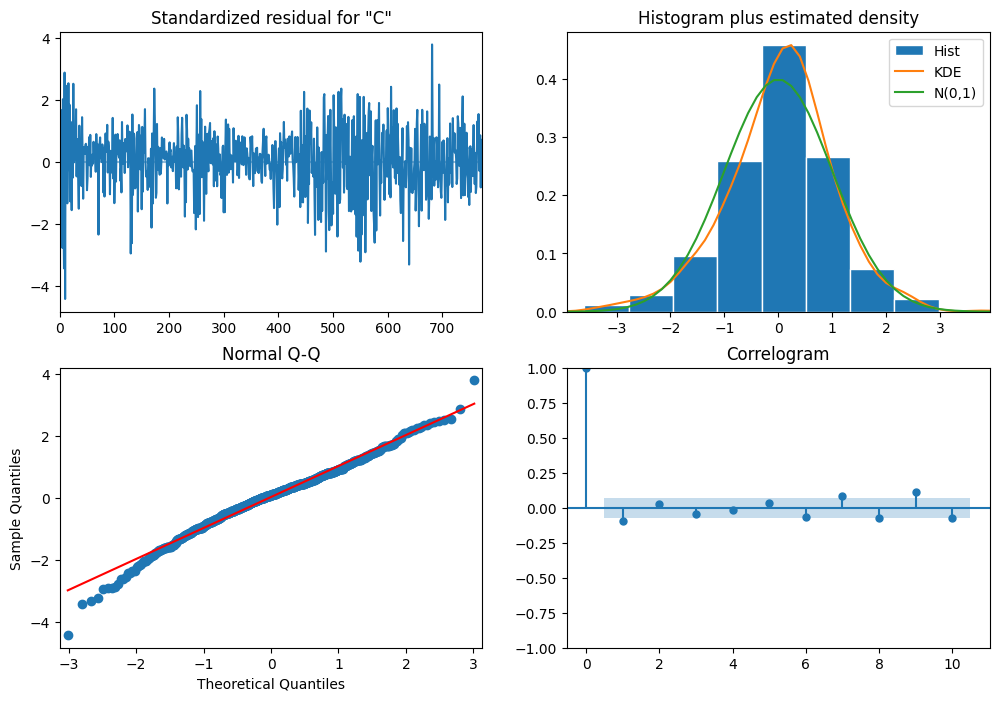

In [132]:
model_results.plot_diagnostics(figsize=(12, 8));

The top-right plot shows the kernel density estimate (KDE) of the standardized residuals, which suggests the errors are Gaussian with a mean close to zero.

Here, the non zero mean suggests that prediction may be biased positively

In [133]:
model_results.resid.describe()

,0
count,774.000000
mean,0.447757
std,9.059974
min,-22.278139
25%,-2.573542
50%,0.494625
75%,3.239341
max,209.577652


Predicting and Forecasting the Model: The model_results variable is a SARIMAXResults object of the statsmodel module, representing the output of the SARIMAX model. It contains a get_prediction() method for performing in-sample prediction and out-of-sample forecasting. It also contains a conf_int() method, which returns the confidence intervals of the predictions, both lower- and upper-bounded, of the fitted parameters, which is at a 95% confidence interval by default.

In [139]:
prediction = model_results.get_prediction(
    start='2020-03-03',
    end='2022-04-29'

)
prediction_ci = prediction.conf_int()

In [140]:
print(prediction.summary_frame())

Close                            mean   mean_se  mean_ci_lower  mean_ci_upper
Date                                                                         
2020-03-03 00:00:00-05:00  209.540088  5.044925     199.652216     219.427960
2020-03-04 00:00:00-05:00  202.820742  5.044925     192.932870     212.708614
2020-03-05 00:00:00-05:00  211.282894  5.044925     201.395022     221.170766
2020-03-06 00:00:00-05:00  204.863665  5.044925     194.975793     214.751537
2020-03-09 00:00:00-04:00  201.407131  5.044925     191.519259     211.295003
...                               ...       ...            ...            ...
2022-04-25 00:00:00-04:00  318.769484  5.044925     308.881612     328.657356
2022-04-26 00:00:00-04:00  322.864301  5.044925     312.976429     332.752173
2022-04-27 00:00:00-04:00  310.677795  5.044925     300.789923     320.565667
2022-04-28 00:00:00-04:00  310.305548  5.044925     300.417676     320.193420
2022-04-29 00:00:00-04:00  321.326277  5.044925     311.438405  

In [141]:
print(prediction_ci)

                           lower Close  upper Close
Date                                               
2020-03-03 00:00:00-05:00   199.652216   219.427960
2020-03-04 00:00:00-05:00   192.932870   212.708614
2020-03-05 00:00:00-05:00   201.395022   221.170766
2020-03-06 00:00:00-05:00   194.975793   214.751537
2020-03-09 00:00:00-04:00   191.519259   211.295003
...                                ...          ...
2022-04-25 00:00:00-04:00   308.881612   328.657356
2022-04-26 00:00:00-04:00   312.976429   332.752173
2022-04-27 00:00:00-04:00   300.789923   320.565667
2022-04-28 00:00:00-04:00   300.417676   320.193420
2022-04-29 00:00:00-04:00   311.438405   331.214149

[546 rows x 2 columns]


We then plot the predicted and forecasted prices against our original dataset, from 2020 onwards. The solid line plot shows the observed values, while the dotted lines plot the five-year rolling predictions trailing closely and bounded by the confidence intervals in the shaded area.

<Figure size 1200x600 with 0 Axes>

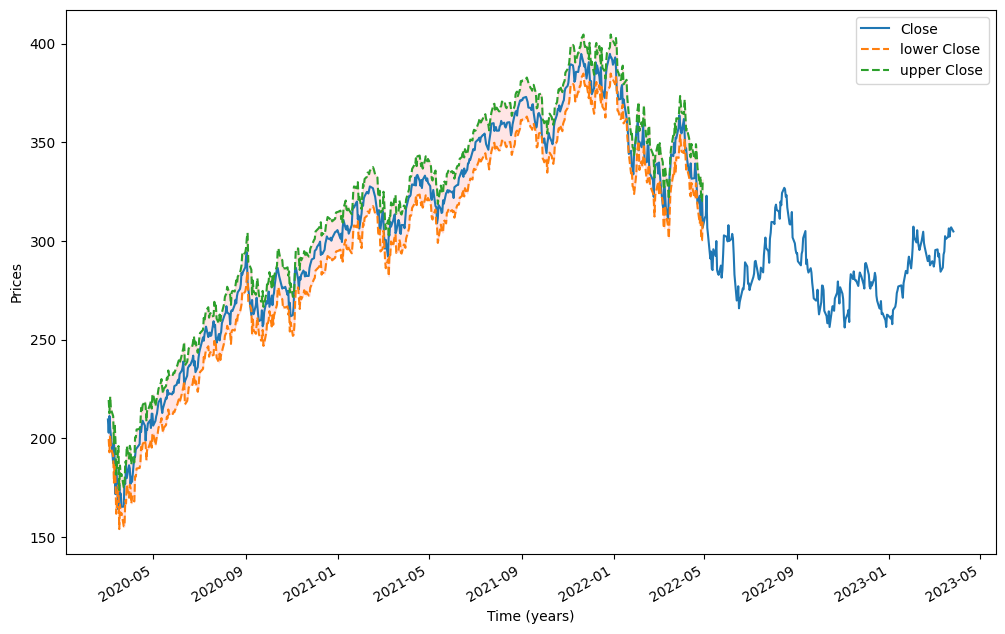

In [142]:
plt.figure(figsize=(12, 6))

ax = analysis['2020':].plot(label='actual')
prediction_ci.plot(
    ax=ax, style=['--', '--'],
    label='predicted/forecasted')

ci_index = prediction_ci.index
lower_ci = prediction_ci.iloc[:, 0]
upper_ci = prediction_ci.iloc[:, 1]

ax.fill_between(ci_index, lower_ci, upper_ci,
    color='r', alpha=.1)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Prices')

plt.legend()
plt.show()

In [144]:
count = 0
for i in range(0,n):
    lower_threshold = prediction_ci['lower Close'][i]
    upper_threshold = prediction_ci['upper Close'][i]
    current_value = analysis[i:].reset_index().iloc[0,1]
#(current_value >= lower_threshold) and
# print(current_value,lower_threshold,upper_threshold)
    # FLag the current data point as "outlier" or "normal" by comparing it with the prediction
    if (current_value <= upper_threshold):
        verdict = "normal"

    else:
        verdict = "outlier"
        count = count+1
print(count, len(prediction_ci), (count/len(prediction_ci)*100))

0 546 0.0
